# Multi-Period Entropy Pooling

This examples shows how to use Entropy Pooling with multi-period data by applying views on different horizons.

It is part of the accompanying code to the Multi-Period Entropy Pooling article: https://antonvorobets.substack.com/p/multi-period-entropy-pooling

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fortitudo.tech import investment_analysis as ia
plt.rcdefaults()

In [2]:
names = ['Materials', 'Energy', 'Financial', 'Industrial', 'Technology', 'Consumer Staples',
         'Utilities', 'Health Care', 'Consumer Discretionary', 'S&P 500']
pnl = np.load('data/simulation_3d_10000.npy')
S, I, H = pnl.shape
S, I, H

(10000, 10, 21)

In [3]:
# For visualization
i = 9
zeros = np.zeros((S, 1))
plt.plot(np.hstack((zeros, pnl[:, i, :])).T, color='blue', alpha=0.5)
plt.title(f'Simulations for {names[i]}')
plt.xlabel('Horizon')
plt.ylabel('Value')
plt.show()

# Viewing some prior statistics

In [4]:
stats_day_10 = ia.multiperiod_individual_stats(
    pnl * 100, instrument_names=names, horizon=10)
display(stats_day_10)

,Mean,Vol,Skew,Kurt,95%-VaR,95%-CVaR,95%-ML,95%-CML
"(0, Materials)",0.577,4.127,-0.101,4.322,6.182,8.546,7.003,9.262
"(1, Energy)",0.746,5.263,-0.056,4.512,7.642,10.466,8.442,11.252
"(2, Financial)",0.631,4.623,-0.159,5.776,6.837,9.925,7.619,10.824
"(3, Industrial)",0.644,3.757,-0.240,4.376,5.494,7.831,6.284,8.461
"(4, Technology)",0.732,4.740,0.009,3.935,7.112,9.476,8.042,10.208
"(5, Consumer Staples)",0.476,2.737,-0.084,3.997,4.000,5.471,4.568,5.977
"(6, Utilities)",0.474,3.325,-0.087,4.100,4.977,6.822,5.561,7.396
"(7, Health Care)",0.524,3.124,0.002,3.847,4.552,6.137,5.165,6.673
"(8, Consumer Discretionary)",0.562,4.119,-0.123,3.959,6.263,8.576,6.972,9.261
"(9, S&P 500)",0.522,3.345,-0.208,4.927,5.048,7.085,5.746,7.692


In [5]:
stats_day_H = ia.multiperiod_individual_stats(pnl * 100, instrument_names=names)
stats_day_H

,Mean,Vol,Skew,Kurt,95%-VaR,95%-CVaR,95%-ML,95%-CML
"(0, Materials)",1.443,5.979,-0.108,4.563,8.330,11.974,9.740,13.271
"(1, Energy)",1.647,7.602,0.029,4.537,10.433,14.766,11.976,16.202
"(2, Financial)",1.523,6.635,-0.242,5.096,9.246,13.899,11.165,15.641
"(3, Industrial)",1.579,5.411,-0.277,4.416,7.331,10.877,8.837,12.159
"(4, Technology)",1.950,6.774,-0.063,3.720,9.425,12.906,11.028,14.244
"(5, Consumer Staples)",1.068,3.860,-0.129,3.651,5.345,7.441,6.346,8.334
"(6, Utilities)",1.103,4.898,-0.077,4.156,6.836,9.595,7.961,10.689
"(7, Health Care)",1.356,4.546,-0.111,3.740,6.191,8.548,7.336,9.588
"(8, Consumer Discretionary)",1.480,5.868,-0.186,3.842,8.478,11.733,9.999,13.018
"(9, S&P 500)",1.374,4.831,-0.316,4.750,6.773,9.923,8.091,11.096


In [6]:
pnl_day_10 = pd.DataFrame(pnl[:, :, 9], columns=names)
pnl_day_H = pd.DataFrame(pnl[:, :, -1], columns=names)
corr_day_10 = ia.correlation_matrix(pnl_day_10)
corr_day_H = ia.correlation_matrix(pnl_day_H)
display(corr_day_10)
display(corr_day_H)

,0,1,2,3,4,5,6,7,8,9
"(0, Materials)",1.000000,0.597799,0.678224,0.804441,0.573652,0.527123,0.451322,0.588658,0.669475,0.768289
"(1, Energy)",0.597799,1.000000,0.516590,0.552906,0.336058,0.338988,0.346965,0.371938,0.382279,0.542991
"(2, Financial)",0.678224,0.516590,1.000000,0.774428,0.581912,0.536983,0.423235,0.596558,0.703833,0.814514
"(3, Industrial)",0.804441,0.552906,0.774428,1.000000,0.692374,0.569717,0.483074,0.648697,0.755658,0.868396
"(4, Technology)",0.573652,0.336058,0.581912,0.692374,1.000000,0.383831,0.349242,0.558286,0.725058,0.880500
"(5, Consumer Staples)",0.527123,0.338988,0.536983,0.569717,0.383831,1.000000,0.561743,0.608539,0.541620,0.618083
"(6, Utilities)",0.451322,0.346965,0.423235,0.483074,0.349242,0.561743,1.000000,0.474277,0.409846,0.525222
"(7, Health Care)",0.588658,0.371938,0.596558,0.648697,0.558286,0.608539,0.474277,1.000000,0.600073,0.734313
"(8, Consumer Discretionary)",0.669475,0.382279,0.703833,0.755658,0.725058,0.541620,0.409846,0.600073,1.000000,0.863313
"(9, S&P 500)",0.768289,0.542991,0.814514,0.868396,0.880500,0.618083,0.525222,0.734313,0.863313,1.000000


,0,1,2,3,4,5,6,7,8,9
"(0, Materials)",1.000000,0.610054,0.681793,0.812444,0.582538,0.537568,0.462109,0.591751,0.675916,0.773542
"(1, Energy)",0.610054,1.000000,0.518455,0.565085,0.357272,0.352493,0.361416,0.385793,0.400510,0.558709
"(2, Financial)",0.681793,0.518455,1.000000,0.773078,0.593139,0.534639,0.425963,0.598087,0.706005,0.815372
"(3, Industrial)",0.812444,0.565085,0.773078,1.000000,0.699505,0.572268,0.494557,0.655956,0.760045,0.869788
"(4, Technology)",0.582538,0.357272,0.593139,0.699505,1.000000,0.403443,0.364695,0.572158,0.734434,0.885081
"(5, Consumer Staples)",0.537568,0.352493,0.534639,0.572268,0.403443,1.000000,0.564671,0.609884,0.545238,0.628047
"(6, Utilities)",0.462109,0.361416,0.425963,0.494557,0.364695,0.564671,1.000000,0.476537,0.413176,0.534805
"(7, Health Care)",0.591751,0.385793,0.598087,0.655956,0.572158,0.609884,0.476537,1.000000,0.605182,0.742747
"(8, Consumer Discretionary)",0.675916,0.400510,0.706005,0.760045,0.734434,0.545238,0.413176,0.605182,1.000000,0.865847
"(9, S&P 500)",0.773542,0.558709,0.815372,0.869788,0.885081,0.628047,0.534805,0.742747,0.865847,1.000000


# Entropy Pooling on multiple horizons
With multiperiod data we can add views on any horizon available in the data. This includes rank views where we can compare the parameters from different instruments and/or horizons.

In [7]:
ep = ia.EntropyPooling(pnl)

ep.add_view('mean', 9, '<=', -0.01, 10)  # The mean of S&P 500 for horizon 10 must at most -1%
ep.add_view('vol', 9, '>=', 0.08, H)  # S&P 500 volatility on horizon H must be at least 8%
ep.add_view('skew', 6, '<=', -0.3, H)  # Skewness for Utilities on horizon H must be at most -0.3
ep.add_view('kurt', 6, '=', 6, 10)  # Kurtosis for Utilities on horizon 10 must be 6
ep.add_rank_view('corr', [[6, 9], [6, 9]], 1, '>=', [H, 10])  # Corr. on horizon H must be at least that of horizon 10 for Utilities and S&P 500
ep.add_rank_view('mean', [6, 7], 1, '=', [10, 10])  # Utilities and HC must have same mean on horizon 10

In [8]:
# Run each of the three heuristics
q_orig = ep.compute_posterior_probability('Original')
q_H1 = ep.compute_posterior_probability('H1')  # Default
q_H2 = ep.compute_posterior_probability('H2')

Posterior probabilities computed in 0.07 seconds with effective number of scenarios 5312 / 10000 and relative entropy 0.6327.
Posterior probabilities computed in 0.2 seconds with effective number of scenarios 7980 / 10000 and relative entropy 0.2257.
Posterior probabilities computed in 0.21 seconds with effective number of scenarios 7699 / 10000 and relative entropy 0.2614.


In [9]:
stats_day_10_orig = ia.multiperiod_individual_stats(100 * pnl, q_orig, names, 10)
stats_day_H_orig = ia.multiperiod_individual_stats(100 * pnl, q_orig, names)
stats_day_10_H1 = ia.multiperiod_individual_stats(100 * pnl, q_H1, names, 10)
stats_day_H_H1 = ia.multiperiod_individual_stats(100 * pnl, q_H1, names)
stats_day_10_H2 = ia.multiperiod_individual_stats(100 * pnl, q_H2, names, 10)
stats_day_H_H2 = ia.multiperiod_individual_stats(100 * pnl, q_H2, names)

corr_orig_10 = ia.correlation_matrix(pnl_day_10, q_orig).values[6, 9]
corr_orig_H = ia.correlation_matrix(pnl_day_H, q_orig).values[6, 9]
corr_H1_10 = ia.correlation_matrix(pnl_day_10, q_H1).values[6, 9]
corr_H1_H = ia.correlation_matrix(pnl_day_H, q_H1).values[6, 9]
corr_H2_10 = ia.correlation_matrix(pnl_day_10, q_H2).values[6, 9]
corr_H2_H = ia.correlation_matrix(pnl_day_H, q_H2).values[6, 9]

print('Statistics for heuristic=Original, day 10:')
display(stats_day_10_orig)
print('Statistics for heuristic=Original, day H:')
display(stats_day_H_orig)
print(f'The correlation between {names[6]} and {names[9]} is {corr_orig_10:.3f} on day 10 and {corr_orig_H:.3f} on day H.\n')

print('Statistics for heuristic=H1, day 10:')
display(stats_day_10_H1)
print('Statistics for heuristic=H1, day H:')
display(stats_day_H_H1)
print(f'The correlation between {names[6]} and {names[9]} is {corr_H1_10:.3f} on day 10 and {corr_H1_H:.3f} on day H.\n')

print('Statistics for heuristic=H2, day 10:')
display(stats_day_10_H2)
print('Statistics for heuristic=H2, day H:')
display(stats_day_H_H2)
print(f'The correlation between {names[6]} and {names[9]} is {corr_H2_10:.3f} on day 10 and {corr_H2_H:.3f} on day H.\n')

Statistics for heuristic=Original, day 10:


,Mean,Vol,Skew,Kurt,95%-VaR,95%-CVaR,95%-ML,95%-CML
"(0, Materials)",-0.712,4.118,-0.418,3.910,7.868,10.465,8.486,11.084
"(1, Energy)",-0.458,5.269,-0.354,4.474,9.032,12.451,9.976,13.236
"(2, Financial)",-1.231,4.710,-0.798,5.681,9.655,13.272,10.245,14.182
"(3, Industrial)",-0.798,3.734,-0.387,4.465,7.285,9.550,7.936,10.078
"(4, Technology)",-1.542,4.800,-0.304,3.528,9.956,12.417,10.674,12.920
"(5, Consumer Staples)",0.257,2.802,0.004,4.550,4.291,5.842,4.895,6.367
"(6, Utilities)",0.474,3.325,-0.045,6.000,4.717,7.041,5.427,7.770
"(7, Health Care)",0.474,3.113,0.069,4.183,4.668,6.214,5.266,6.805
"(8, Consumer Discretionary)",-1.378,4.138,-0.304,3.614,8.337,10.996,9.106,11.581
"(9, S&P 500)",-1.000,3.345,-0.521,4.366,6.741,8.922,7.343,9.485


Statistics for heuristic=Original, day H:


,Mean,Vol,Skew,Kurt,95%-VaR,95%-CVaR,95%-ML,95%-CML
"(0, Materials)",1.432,8.571,0.224,4.771,12.469,17.645,13.456,18.844
"(1, Energy)",1.537,9.749,-0.018,4.604,13.463,20.559,15.549,21.917
"(2, Financial)",1.377,9.889,-0.136,5.116,13.831,22.265,15.684,23.460
"(3, Industrial)",1.379,7.753,-0.027,4.273,11.467,16.682,12.422,17.471
"(4, Technology)",1.675,10.512,0.628,4.340,14.500,19.326,15.560,20.293
"(5, Consumer Staples)",1.275,4.480,-0.214,3.819,5.960,8.937,6.901,9.982
"(6, Utilities)",1.103,4.898,-0.300,5.593,6.404,10.631,8.031,12.311
"(7, Health Care)",2.323,5.827,0.032,3.871,6.915,10.308,8.014,11.374
"(8, Consumer Discretionary)",1.396,9.051,0.508,4.413,12.692,17.505,13.507,18.517
"(9, S&P 500)",1.374,8.000,0.438,4.979,10.583,16.128,11.610,16.976


The correlation between Utilities and S&P 500 is 0.446 on day 10 and 0.446 on day H.

Statistics for heuristic=H1, day 10:


,Mean,Vol,Skew,Kurt,95%-VaR,95%-CVaR,95%-ML,95%-CML
"(0, Materials)",-0.920,5.330,-0.761,5.106,11.119,15.395,11.741,15.704
"(1, Energy)",-0.855,6.926,-1.219,6.891,12.379,20.784,13.595,21.137
"(2, Financial)",-1.241,6.586,-1.489,7.489,12.784,21.465,13.639,22.093
"(3, Industrial)",-0.906,5.197,-1.213,6.252,10.231,16.057,10.440,16.298
"(4, Technology)",-1.056,5.854,-0.505,4.394,11.788,15.844,12.590,16.534
"(5, Consumer Staples)",-0.388,3.407,-0.790,4.934,6.407,9.668,6.815,9.954
"(6, Utilities)",-0.479,3.867,-0.571,6.000,7.805,10.471,8.181,11.255
"(7, Health Care)",-0.479,3.810,-0.433,4.414,7.457,10.201,7.799,10.464
"(8, Consumer Discretionary)",-0.975,5.168,-0.618,4.255,10.780,14.369,11.448,14.676
"(9, S&P 500)",-1.000,4.670,-1.117,6.110,9.620,14.588,10.030,14.825


Statistics for heuristic=H1, day H:


,Mean,Vol,Skew,Kurt,95%-VaR,95%-CVaR,95%-ML,95%-CML
"(0, Materials)",-0.095,9.101,0.334,7.887,18.117,22.502,19.719,24.120
"(1, Energy)",-0.064,10.862,-0.098,6.799,20.214,27.899,20.974,28.874
"(2, Financial)",-0.569,10.580,-0.618,6.613,20.846,30.675,22.421,32.199
"(3, Industrial)",-0.080,8.631,-0.309,6.902,15.872,23.439,17.377,24.497
"(4, Technology)",0.146,9.545,0.055,5.060,17.766,22.451,19.674,23.510
"(5, Consumer Staples)",0.132,5.268,-0.733,4.917,9.891,13.952,10.947,14.967
"(6, Utilities)",0.130,7.116,-0.300,7.888,12.331,19.335,13.626,20.187
"(7, Health Care)",0.321,6.161,-0.351,4.555,10.996,15.170,12.342,16.251
"(8, Consumer Discretionary)",-0.232,8.443,-0.413,4.693,16.627,21.699,18.131,22.890
"(9, S&P 500)",-0.224,8.000,-0.136,7.270,16.059,21.536,16.811,22.626


The correlation between Utilities and S&P 500 is 0.687 on day 10 and 0.785 on day H.

Statistics for heuristic=H2, day 10:


,Mean,Vol,Skew,Kurt,95%-VaR,95%-CVaR,95%-ML,95%-CML
"(0, Materials)",-1.202,5.461,-0.830,5.080,11.902,16.193,12.562,16.494
"(1, Energy)",-1.171,7.152,-1.298,6.841,13.933,22.225,14.919,22.481
"(2, Financial)",-1.607,6.798,-1.548,7.257,14.949,22.857,15.449,23.430
"(3, Industrial)",-1.190,5.326,-1.248,6.103,11.024,16.963,11.321,17.190
"(4, Technology)",-1.375,5.944,-0.565,4.414,12.944,16.545,13.382,17.206
"(5, Consumer Staples)",-0.547,3.468,-0.829,4.896,6.966,10.088,7.415,10.344
"(6, Utilities)",-0.667,3.933,-0.617,6.000,7.805,10.952,8.777,11.729
"(7, Health Care)",-0.667,3.843,-0.443,4.344,7.771,10.484,8.395,10.725
"(8, Consumer Discretionary)",-1.259,5.264,-0.667,4.214,12.170,14.952,12.689,15.205
"(9, S&P 500)",-1.281,4.794,-1.181,6.042,10.615,15.435,10.949,15.655


Statistics for heuristic=H2, day H:


,Mean,Vol,Skew,Kurt,95%-VaR,95%-CVaR,95%-ML,95%-CML
"(0, Materials)",-0.082,9.089,0.385,7.886,18.080,22.217,19.820,24.004
"(1, Energy)",-0.079,10.938,-0.114,6.780,20.214,28.287,21.591,29.328
"(2, Financial)",-0.581,10.596,-0.582,6.529,21.375,30.631,23.525,32.357
"(3, Industrial)",-0.090,8.653,-0.298,6.933,15.625,23.435,17.377,24.620
"(4, Technology)",0.146,9.546,0.081,5.111,17.204,22.415,19.674,23.573
"(5, Consumer Staples)",0.122,5.283,-0.728,4.916,9.992,13.982,11.054,15.017
"(6, Utilities)",0.147,7.117,-0.300,7.997,11.791,19.349,13.501,20.181
"(7, Health Care)",0.327,6.145,-0.311,4.539,10.483,14.999,12.289,16.125
"(8, Consumer Discretionary)",-0.237,8.454,-0.382,4.716,16.557,21.596,18.344,22.866
"(9, S&P 500)",-0.224,8.000,-0.098,7.279,15.970,21.412,17.198,22.630


The correlation between Utilities and S&P 500 is 0.699 on day 10 and 0.783 on day H.



# Visualization of the different heuristics

Day 10


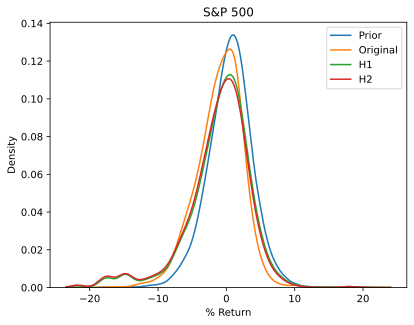

Day H


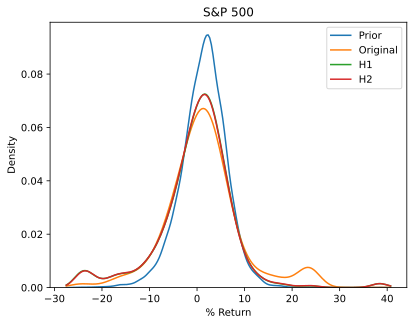

In [10]:
i = 9
print('Day 10')
ia.density(pnl_day_10, i)
ia.density(pnl_day_10, i, q_orig)
ia.density(pnl_day_10, i, q_H1)
ia.density(pnl_day_10, i, q_H2)
plt.legend(['Prior', 'Original', 'H1', 'H2'])
plt.show()

print('Day H')
ia.density(pnl_day_H, i)
ia.density(pnl_day_H, i, q_orig)
ia.density(pnl_day_H, i, q_H1)
ia.density(pnl_day_H, i, q_H2)
plt.legend(['Prior', 'Original', 'H1', 'H2'])
plt.show()

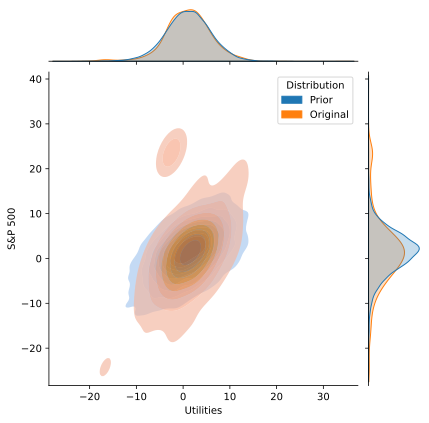

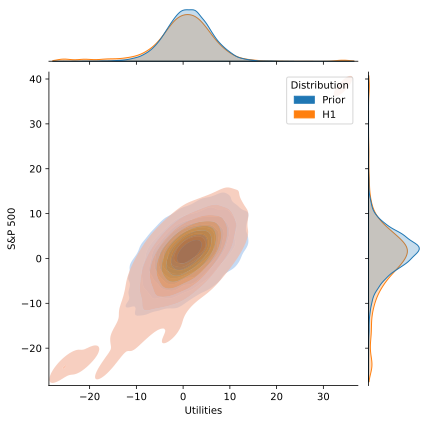

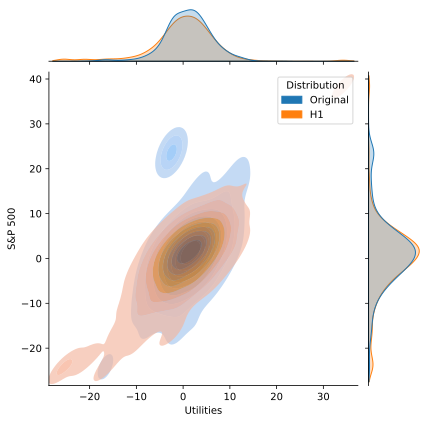

In [11]:
prior = np.ones(S) / S
ia.joint_density(pnl_day_H, [6, 9], {'Prior': prior, 'Original': q_orig})
plt.show()
ia.joint_density(pnl_day_H, [6, 9], {'Prior': prior, 'H1': q_H1})
plt.show()
ia.joint_density(pnl_day_H, [6, 9], {'Original': q_orig, 'H1': q_H1})
plt.show()

# License
This Jupyter Notebook illustration of the <a href="http://facebook.tech/solutions">Investment Analysis module</a> © 2026 by <a href="https://fortitudo.tech/">Fortitudo Technologies</a> is licensed under <a href="https://creativecommons.org/licenses/by-nc-nd/4.0/">CC BY-NC-ND 4.0</a>. Note that the <a href="http://facebook.tech/solutions">Investment Analysis module</a> has a separate proprietary license.